In [1]:
import os,gc, polars as pl
import mysql.connector
from datetime import datetime, timedelta

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

In [6]:
conn = mysql.connector.connect(
    host="118.179.149.162",
    user="gazu",
    password="X9!qR7@MZf#2A$wL8pE",
    database="padakhep",
    port=8837,
    buffered=True
)

In [7]:
query ="""
SELECT
zones.name zonename,
zones.pmuk_id,
tl.shamity_id,
lc.name as loan_component,
l.loan_product_id,
l.member_id,
l.id loan_id,
l.disbursed_date,
l.loan_amount,
l.total_interest,
l.balance,
ls.id  as schedule_id,
tl.id transaction_id,
l.next_unpaid_schedule_id,
l.is_active loan_activity,
l.loan_condition,
l.status loan_status,
tl.transaction_type,
l.overdue,


-- loan_shcedule
ls.kisti_no,
ls.due_date,
tl.date_of_action transaction_date,
ls.kisti_amount,
ls.principal_amount,
ls.interest_amount,
ls.paid_amount,
tl.amount transaction_amount,
ls.paid_principal,
ls.paid_interest,
ls.kisti_paid_date,
ls.kisti_status,

-- transaction_loans
tl.pre_sthiti,
tl.pre_bokeya_sthiti,
tl.post_sthiti,
tl.post_bokeya_sthiti,
tl.principal,
tl.service_charge
from loans l
left join loan_schedules ls on ls.loan_id = l.id
left join transactions_loans tl  on tl.loan_id = l.id and tl.loan_schedule_id = ls.id
LEFT JOIN loan_products ON
	loan_products.id = l.loan_product_id
LEFT JOIN loan_components lc ON
	lc.id = loan_products.component_id
LEFT JOIN shamities on shamities.id = tl.shamity_id
LEFT JOIN zones on zones.pmuk_id = LEFT(shamities.pmuk_id, 2)
where tl.date_of_action >= %s AND  tl.date_of_action <= %s
"""
###where ls.due_date >= %s AND  ls.due_date <= %s

In [8]:
start = datetime(2026, 2, 1)
end = datetime(2026, 4, 30)

In [9]:
os.makedirs('loan_data', exist_ok =True)

In [ ]:
current_start = start

while current_start <= end:

    current_end = min(current_start + timedelta(days=3), end + timedelta(days=1))

    print(f"Fetching {current_start} -> {current_end}")

    df = pl.read_database(
        query,
        conn,
        execute_options={
            "params": (
                current_start,
                current_end,
            )
        }
    )
    file_name = current_end.strftime("%Y-%m-%d")
    df.write_parquet(f"loan_data/{file_name}.parquet")
    del df
    gc.collect()
    current_start = current_end
print('done')

Fetching 2026-02-01 00:00:00 -> 2026-02-04 00:00:00


### EDA

In [2]:
import pandas as pd
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
files  = glob('loan_data/*.parquet')

df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)
df.to_parquet("loan_information.parquet", index=False)

In [108]:
df = pd.read_parquet("loan_information.parquet")
df.shape

(3429893, 37)

In [4]:
df = df.drop(columns=['pmuk_id'], axis=1)
df.head()

,zonename,shamity_id,loan_component,loan_product_id,member_id,loan_id,disbursed_date,loan_amount,total_interest,balance,schedule_id,transaction_id,next_unpaid_schedule_id,loan_activity,loan_condition,loan_status,transaction_type,overdue,kisti_no,due_date,transaction_date,kisti_amount,principal_amount,interest_amount,paid_amount,transaction_amount,paid_principal,paid_interest,kisti_paid_date,kisti_status,pre_sthiti,pre_bokeya_sthiti,post_sthiti,post_bokeya_sthiti,principal,service_charge
0,Cumilla Zone,18723,JAGORON,41,1204302,1903973,2025-09-09,80000.00,10800.00,34800.0,78078903,69660752,78078906,Yes,regular,active,advance,0,5,2026-02-10,2026-02-01,7600,6696,904,7600,6000,6696,904,2026-02-01,paid,58800,0,52800,0,5286,714
1,Cumilla Zone,18723,JAGORON,41,1204302,1903973,2025-09-09,80000.00,10800.00,34800.0,78078904,69660753,78078906,Yes,regular,active,advance,0,6,2026-03-10,2026-02-01,7600,6696,904,7600,2000,6696,904,2026-03-03,paid,52800,0,50800,0,1762,238
2,Cumilla Zone,24262,LIVELIHOOD IMPROVEMENT LOAN,48,879050,1336295,2024-04-04,24000.00,3240.00,17740.0,55184033,69660754,0,Yes,bad_loan,active,bokeya,17740,4,2024-08-12,2026-02-01,2280,2009,271,2280,500,2010,270,2026-02-19,paid,18740,18740,18240,18240,441,59
3,Dhaka North Zone,9031,JAGORON,41,1030179,1543189,2024-11-17,50000.00,6750.00,17750.0,64565881,69660755,0,Yes,doubtful,active,bokeya,17750,8,2025-07-20,2026-02-01,4750,4185,565,4750,1000,4185,565,2026-03-08,paid,20750,20750,19750,19750,881,119
4,Cumilla Zone,19694,AGROSOR,22,1181043,1854277,2025-07-27,300000.00,40500.00,84000.0,76356803,69660756,76356807,Yes,regular,active,advance,0,6,2026-02-18,2026-02-01,28500,25110,3390,28500,28500,25110,3390,2026-02-01,paid,198000,0,169500,0,25110,3390


In [71]:
df.columns

Index(['zonename', 'shamity_id', 'loan_component', 'loan_product_id',
       'member_id', 'loan_id', 'disbursed_date', 'loan_amount',
       'total_interest', 'balance', 'schedule_id', 'transaction_id',
       'next_unpaid_schedule_id', 'loan_activity', 'loan_condition',
       'loan_status', 'transaction_type', 'overdue', 'kisti_no', 'due_date',
       'transaction_date', 'kisti_amount', 'principal_amount',
       'interest_amount', 'paid_amount', 'transaction_amount',
       'paid_principal', 'paid_interest', 'kisti_paid_date', 'kisti_status',
       'pre_sthiti', 'pre_bokeya_sthiti', 'post_sthiti', 'post_bokeya_sthiti',
       'principal', 'service_charge'],
      dtype='object')

In [72]:
from IPython.display import display
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': [df[col].dtype for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Missing Values': [df[col].isnull().sum() for col in df.columns]
})

display(summary)

,Column,Data Type,Unique Values,Missing Values
0,zonename,object,19,0
1,shamity_id,int64,26773,0
2,loan_component,object,31,0
3,loan_product_id,int64,133,0
4,member_id,int64,437755,0
5,loan_id,int64,492743,0
6,disbursed_date,object,2164,0
7,loan_amount,object,302,0
8,total_interest,object,4905,0
9,balance,float64,37786,0


In [73]:
df.describe()

,shamity_id,loan_product_id,member_id,loan_id,balance,schedule_id,transaction_id,next_unpaid_schedule_id,overdue,kisti_no,kisti_amount,principal_amount,interest_amount,paid_amount,transaction_amount,paid_principal,paid_interest,pre_sthiti,pre_bokeya_sthiti,post_sthiti,post_bokeya_sthiti,principal,service_charge
count,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06,3.429893e+06
mean,1.517759e+04,3.444704e+01,8.550925e+05,1.846128e+06,4.424822e+04,7.541388e+07,7.128275e+07,5.428650e+07,3.258834e+03,2.220747e+01,5.105687e+03,4.491795e+03,6.138922e+02,4.932922e+03,4.366161e+03,4.341352e+03,5.915750e+02,6.052232e+04,4.702428e+03,5.615617e+04,3.454868e+03,3.843260e+03,5.229014e+02
std,8.889067e+03,2.659357e+01,3.548602e+05,2.641546e+05,8.572034e+04,1.032576e+07,9.428263e+05,3.682064e+07,1.887733e+04,1.424519e+01,9.523793e+03,8.330659e+03,1.219459e+03,9.301904e+03,8.733162e+03,8.143238e+03,1.185554e+03,1.029102e+05,2.042663e+04,9.709087e+04,1.929955e+04,7.652465e+03,1.103518e+03
min,2.000000e+00,1.000000e+00,4.000000e+00,5.400000e+01,0.000000e+00,2.314000e+03,6.966075e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.461000e+03,2.500000e+01,6.072910e+05,1.785780e+06,1.500000e+02,7.360388e+07,7.045775e+07,0.000000e+00,0.000000e+00,9.000000e+00,1.250000e+03,1.106000e+03,1.440000e+02,1.250000e+03,1.000000e+03,1.106000e+03,1.440000e+02,1.435000e+04,0.000000e+00,1.260000e+04,0.000000e+00,8.850000e+02,1.150000e+02
50%,1.462600e+04,2.500000e+01,9.670640e+05,1.876939e+06,2.195800e+04,7.720583e+07,7.126967e+07,7.708048e+07,0.000000e+00,2.200000e+01,2.000000e+03,1.770000e+03,2.300000e+02,2.000000e+03,1.750000e+03,1.769000e+03,2.300000e+02,3.330000e+04,0.000000e+00,3.080000e+04,0.000000e+00,1.549000e+03,2.010000e+02
75%,2.294300e+04,2.900000e+01,1.148960e+06,1.988407e+06,5.040000e+04,8.057496e+07,7.208460e+07,8.054004e+07,0.000000e+00,3.500000e+01,4.750000e+03,4.185000e+03,5.650000e+02,4.560000e+03,3.500000e+03,3.982000e+03,5.180000e+02,6.570000e+04,0.000000e+00,6.120000e+04,0.000000e+00,3.084000e+03,4.030000e+02
max,3.153000e+04,1.980000e+02,1.323511e+06,2.177718e+06,4.160000e+06,8.606991e+07,7.294833e+07,8.606991e+07,1.531583e+06,9.200000e+01,4.750000e+05,4.185020e+05,8.942500e+04,4.750000e+05,4.750000e+05,4.185020e+05,8.942500e+04,4.960000e+06,1.681583e+06,4.610000e+06,1.670000e+06,4.185020e+05,8.942500e+04


In [74]:
df["due_date"] = pd.to_datetime(
    df["due_date"],
    errors="coerce"
)
df["due_date"] = df["due_date"].dt.normalize()

In [75]:
df['due_date'].nunique()

2449

In [23]:
df['due_date'].max().date()

datetime.date(2027, 9, 9)

In [19]:
int(df['kisti_amount'].sum())

17511960959

In [20]:
int(df['transaction_amount'].sum())

14975464722

In [39]:
print('Kisti_Amount',int(df.loc[df['due_date'] >= '2026-02-01', 'kisti_amount'].sum()))
print(f"Paid Amount Against those Kisti_amount - {int(df.loc[df['due_date'] >= '2026-02-01', 'transaction_amount'].sum())}")
print('overdue Amount within 3 months',int(df.loc[df['due_date'] >= '2026-02-01', 'kisti_amount'].sum()) - int(df.loc[df['due_date'] >= '2026-02-01', 'transaction_amount'].sum()))

Kisti_Amount 16071394106
Paid Amount Against those Kisti_amount - 14531561110
overdue Amount within 3 months 1539832996


In [43]:
print('unique loan Schedule',df['schedule_id'].nunique())
print('transaction against that loan',df['transaction_id'].nunique())
print(
    'Not any transaction_happen',
    df['transaction_date'].isna().sum()
)

unique loan Schedule 2961145
transaction against that loan 3264633
Not any transaction_happen 0


In [17]:
(df.groupby(['schedule_id', 'transaction_id', 'kisti_amount', 'transaction_amount'])
 .size().reset_index(name='count').head(10))

,schedule_id,transaction_id,kisti_amount,transaction_amount,count
0,2314,72661004,38400,3000,1
1,2672,70280143,40200,2000,1
2,2672,70633437,40200,1000,1
3,2672,71244957,40200,1500,1
4,2672,72015270,40200,2000,1
5,2672,72242445,40200,2000,1
6,2672,72536727,40200,1500,1
7,2672,72897286,40200,1000,1
8,5338,72125765,14400,1000,1
9,5540,70278190,24000,500,1


In [138]:
# zone_summary = df.groupby('zonename').agg(
#     loan_count=('loan_id', 'count'),
#     total_kisti_amount=('kisti_amount', 'sum'),
#     total_paid_amount=('transaction_amount', 'sum')
# )
# zone_summary['overdue_amount'] = (
#     zone_summary['total_kisti_amount'] -
#     zone_summary['total_paid_amount']
# )

# zone_summary.sort_index(ascending=False)

In [109]:
## datetime conversion
df["due_date"]        = pd.to_datetime(df["due_date"])
df["kisti_paid_date"] = pd.to_datetime(df["kisti_paid_date"])
df["transaction_date"]= pd.to_datetime(df["transaction_date"])
df["disbursed_date"]  = pd.to_datetime(df["disbursed_date"])
df["month"]           = df["due_date"].dt.to_period("M")

In [110]:
def safe_div(a, b, fill=0.0):
    return np.where(b == 0, fill, a / b)

df["collection_rate"]        = safe_div(df["paid_amount"], df["kisti_amount"]) * 100
df["interest_recovery_rate"] = safe_div(df["paid_interest"], df["interest_amount"]) * 100
df["delay_days"]             = (df["kisti_paid_date"] - df["due_date"]).dt.days
df["is_paid"]                = df["kisti_status"].str.lower().str.strip() == "paid"
df["balance_change"]         = df["pre_sthiti"] - df["post_sthiti"]
df["expected_change"]        = df["principal"].fillna(0) + df["service_charge"].fillna(0)
df["recon_gap"]              = (df["balance_change"] - df["expected_change"]).abs()

print("✅ Data loaded:", df.shape)
print(df.dtypes)

✅ Data loaded: (3429893, 45)
zonename                           object
pmuk_id                            object
shamity_id                          int64
loan_component                     object
loan_product_id                     int64
member_id                           int64
loan_id                             int64
disbursed_date             datetime64[ns]
loan_amount                        object
total_interest                     object
balance                           float64
schedule_id                         int64
transaction_id                      int64
next_unpaid_schedule_id             int64
loan_activity                      object
loan_condition                     object
loan_status                        object
transaction_type                   object
overdue                             int64
kisti_no                            int64
due_date                   datetime64[ns]
transaction_date           datetime64[ns]
kisti_amount                        int64
princ

In [111]:
print("\n" + "="*55)
print("  ANALYSIS 1: OVERDUE & DEFAULT ANALYSIS")
print("="*55)
loan_level = (
    df.groupby(["loan_id", "zonename"], dropna=False)
    .agg(
        total_overdue_amt=("overdue", "first")
    )
    .reset_index()
)

overdue_by_zone = (
    loan_level.groupby("zonename", dropna=False)
    .agg(
        total_loans       = ("loan_id", "nunique"),

        overdue_loans     = ("total_overdue_amt", lambda x: (x > 0).sum()),
        total_overdue_amt = ("total_overdue_amt", "sum"),
        avg_overdue       = ("total_overdue_amt", "mean"),
    )
    .assign(
        overdue_rate=lambda x: safe_div(
            x["overdue_loans"],
            x["total_loans"]
        ) * 100
    )
    .sort_values("total_overdue_amt", ascending=False)
    .reset_index()
)

print(overdue_by_zone.to_string(index=False))


  ANALYSIS 1: OVERDUE & DEFAULT ANALYSIS
                zonename  total_loans  overdue_loans  total_overdue_amt  avg_overdue  overdue_rate
        Dhaka South Zone        17725           3329          201864640 11388.696192     18.781382
            Jashore Zone        27295           5377          198052633  7256.004140     19.699579
           Faridpur Zone        24463           4354          185824650  7596.151331     17.798308
           Rajshahi Zone        29826           5104          183442528  6150.423389     17.112586
        Dhaka North Zone        18817           3561          180316789  9582.653399     18.924377
           Dinajpur Zone        35017           4458          168347310  4807.588029     12.730959
            Cumilla Zone        24299           3111          166137056  6837.197251     12.802996
           Barishal Zone        27491           4239          156248900  5683.638282     15.419592
            B-Baria Zone        44287           3870          14818

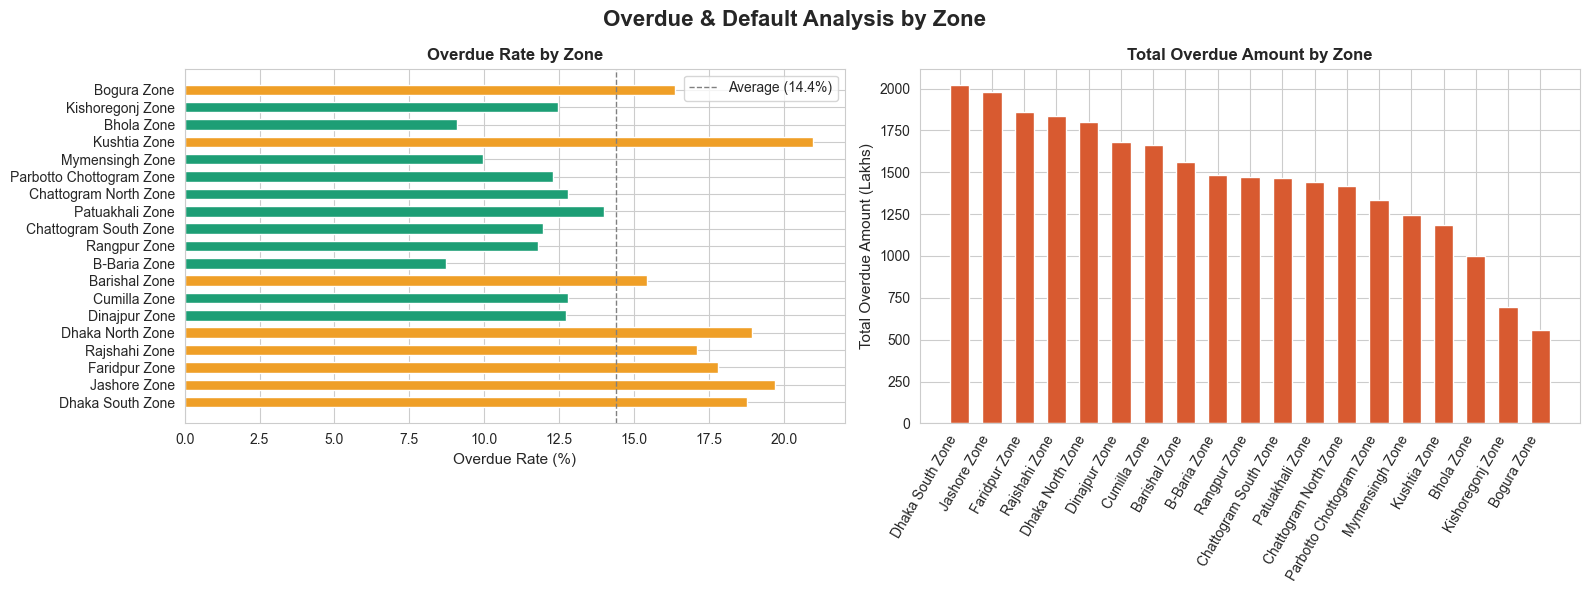

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Overdue & Default Analysis by Zone", fontsize=16, fontweight="bold")

axes[0].barh(
    overdue_by_zone["zonename"],
    overdue_by_zone["overdue_rate"],
    color=[
        "#E24B4A" if r > 30 else "#EF9F27" if r > 15 else "#1D9E75"
        for r in overdue_by_zone["overdue_rate"]
    ],
    height=0.6  # adds spacing between bars
)

axes[0].set_xlabel("Overdue Rate (%)", fontsize=11)
axes[0].set_title("Overdue Rate by Zone", fontsize=12, fontweight="bold")

avg_rate = overdue_by_zone["overdue_rate"].mean()
axes[0].axvline(
    avg_rate,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Average ({avg_rate:.1f}%)"
)

axes[0].legend()

axes[1].bar(
    overdue_by_zone["zonename"],
    overdue_by_zone["total_overdue_amt"] / 1e5,
    color="#D85A30",
    width=0.6  # adds gap between bars
)

axes[1].set_ylabel("Total Overdue Amount (Lakhs)", fontsize=11)
axes[1].set_title("Total Overdue Amount by Zone", fontsize=12, fontweight="bold")

axes[1].tick_params(axis="x", rotation=35, labelsize=10)

# spacing between subplots
plt.subplots_adjust(wspace=0.3)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
# plt.savefig("01_overdue_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
collection = (
        df.groupby(["zonename", "shamity_id"], dropna=False)
        .agg(
            scheduled = ("kisti_amount", "sum"),
            collected = ("paid_amount",  "sum"),
        )
        .assign(
            collection_rate = lambda x: safe_div(x["collected"], x["scheduled"]) * 100,
            shortfall       = lambda x: x["scheduled"] - x["collected"],
        )
        .reset_index()
    )

zone_summary = (
    collection.groupby("zonename")
    .agg(
        total_scheduled_amount = ("scheduled",       "sum"),
        total_collected_amount = ("collected",       "sum"),
        avg_rate        = ("collection_rate", "mean"),
        total_shortfall = ("shortfall",       "sum"),
    )
    .sort_values("avg_rate", ascending=False)
    .reset_index()
)

print("\n── Zone-level summary ──")
print(zone_summary.to_string(index=False))


── Zone-level summary ──
                zonename  total_scheduled_amount  total_collected_amount  avg_rate  total_shortfall
         Patuakhali Zone               798602169               783452893 97.668186         15149276
            Rangpur Zone               869788285               849258109 97.496531         20530176
   Chattogram North Zone               832600741               815812946 97.492334         16787795
              Bhola Zone              1051371910              1023406232 97.210507         27965678
Parbotto Chottogram Zone               616601444               602843831 97.194194         13757613
            B-Baria Zone              1785773890              1735748152 96.870590         50025738
   Chattogram South Zone               994656542               971032403 96.868298         23624139
           Dinajpur Zone               961476181               935451029 96.807511         26025152
             Bogura Zone               297711755               288996568 9

In [90]:
worst_shamities = collection.sort_values("collection_rate").head(10)
print("\n── Bottom 10 Shamities ──")
print(worst_shamities[["zonename","shamity_id","scheduled","collected",
                        "collection_rate","shortfall"]].to_string(index=False))


── Bottom 10 Shamities ──
        zonename  shamity_id  scheduled  collected  collection_rate  shortfall
Dhaka South Zone         226       2500        117         4.680000       2383
Dhaka South Zone         157      25000       2320         9.280000      22680
   Rajshahi Zone       23709      75750      10569        13.952475      65181
     Bogura Zone       25910       9500       1660        17.473684       7840
Dhaka South Zone        8677       9000       1610        17.888889       7390
   Rajshahi Zone       16153      90500      18177        20.085083      72323
   Barishal Zone       18691       2250        500        22.222222       1750
    Jashore Zone       14445      38000       9836        25.884211      28164
   Barishal Zone        9358       9500       2460        25.894737       7040
Dhaka South Zone        8674       2250        607        26.977778       1643


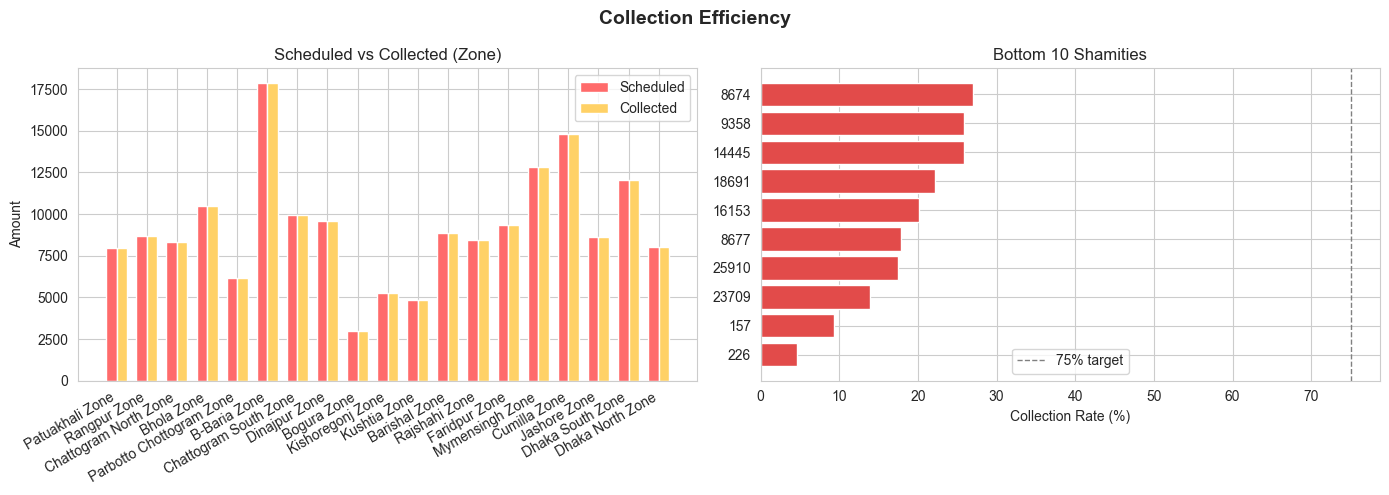

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Collection Efficiency", fontsize=14, fontweight="bold")

# Grouped bar — scheduled vs collected per zone
x = np.arange(len(zone_summary))
w = 0.35
axes[0].bar(x - w/2, zone_summary["total_scheduled_amount"]/1e5, w,
            label="Scheduled", color="#FF6B6B")
axes[0].bar(x + w/2, zone_summary["total_scheduled_amount"]/1e5, w,
            label="Collected",  color="#FFD166")
axes[0].set_xticks(x)
axes[0].set_xticklabels(zone_summary["zonename"], rotation=30, ha="right")
axes[0].set_ylabel("Amount")
axes[0].set_title("Scheduled vs Collected (Zone)")
axes[0].legend()

# Horizontal bar — worst shamities
axes[1].barh(
    worst_shamities["shamity_id"].astype(str),
    worst_shamities["collection_rate"],
    color="#E24B4A"
)
axes[1].axvline(75, color="gray", linestyle="--", linewidth=1, label="75% target")
axes[1].set_xlabel("Collection Rate (%)")
axes[1].set_title("Bottom 10 Shamities")
axes[1].legend()

plt.tight_layout()
plt.savefig("02_collection_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

In [95]:
start = "2025-11"
end   = "2026-05"

df_filtered = df[
    (df["month"] >= start) &
    (df["month"] <= end)
]

monthly = (
    df_filtered.groupby("month")
    .agg(
        total_due       = ("kisti_amount",   "sum"),
        total_collected = ("paid_amount",    "sum"),
        total_principal = ("paid_principal", "sum"),
        total_interest  = ("paid_interest",  "sum"),
        avg_delay_days       = ("delay_days",     "mean"),
        loan_count      = ("loan_id",        "nunique"),
    )
    .assign(collection_rate=lambda x: safe_div(x["total_collected"], x["total_due"]) * 100)
    .reset_index()
)

monthly["month_str"] = monthly["month"].astype(str)

print(monthly.to_string(index=False))

  month  total_due  total_collected  total_principal  total_interest  avg_delay_days  loan_count  collection_rate month_str
2025-11   78250799         65880684         58147645         7733039      130.752911        5105        84.191708   2025-11
2025-12   92535077         79973476         70527942         9445534       98.037622        5570        86.425039   2025-12
2026-01  148461926        132362463        116513059        15849404       60.429478        7476        89.155830   2026-01
2026-02 4602421508       4585250632       4036347381       548903251        1.143484      361855        99.626916   2026-02
2026-03 4226819428       4212246184       3709384322       502875204       -4.102983      354045        99.655220   2026-03
2026-04 5483737325       5465608500       4805601927       660009771       -4.853205      396290        99.669407   2026-04
2026-05 1356109331       1172138383       1031768121       140370262      -31.821268      123467        86.433915   2026-05


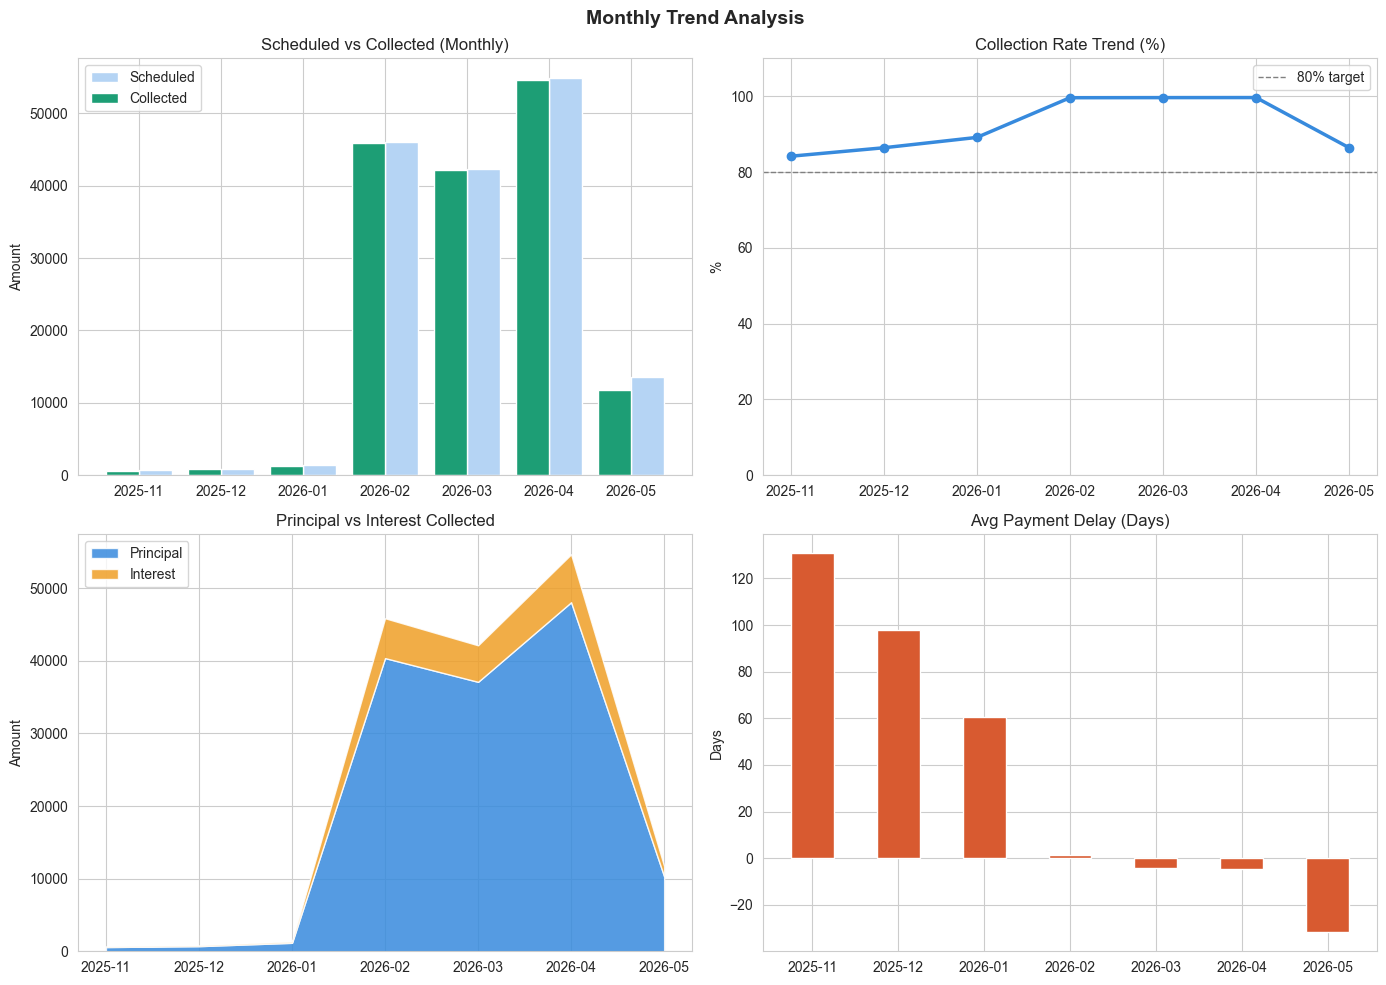

In [137]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Monthly Trend Analysis", fontsize=14, fontweight="bold")

# 1. Collection trend
axes[0,0].bar(monthly["month_str"], monthly["total_due"]/1e5,
              label="Scheduled", color="#B5D4F4", width=0.4, align="edge")
axes[0,0].bar(monthly["month_str"], monthly["total_collected"]/1e5,
              label="Collected",  color="#1D9E75", width=-0.4, align="edge")
axes[0,0].set_title("Scheduled vs Collected (Monthly)")
axes[0,0].set_ylabel("Amount")
axes[0,0].legend()

# 2. Collection rate line
axes[0,1].plot(monthly["month_str"], monthly["collection_rate"],
               marker="o", color="#378ADD", linewidth=2.5)
axes[0,1].axhline(80, color="gray", linestyle="--", linewidth=1, label="80% target")
axes[0,1].set_title("Collection Rate Trend (%)")
axes[0,1].set_ylabel("%")
axes[0,1].set_ylim(0, 110)
axes[0,1].legend()

# 3. Principal vs Interest
axes[1,0].stackplot(
    monthly["month_str"],
    monthly["total_principal"]/1e5,
    monthly["total_interest"]/1e5,
    labels=["Principal","Interest"],
    colors=["#378ADD","#EF9F27"],
    alpha=0.85
)
axes[1,0].set_title("Principal vs Interest Collected")
axes[1,0].set_ylabel("Amount")
axes[1,0].legend(loc="upper left")

# 4. Avg delay
axes[1,1].bar(monthly["month_str"], monthly["avg_delay_days"].fillna(0),
              color="#D85A30", width=0.5)
axes[1,1].set_title("Avg Payment Delay (Days)")
axes[1,1].set_ylabel("Days")

plt.tight_layout()
plt.savefig("03_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [98]:
status_dist = df["kisti_status"].value_counts(normalize=True) * 100
print("\n── Overall kisti status ──")
print(status_dist.round(2).to_string())

# Zone-wise pivot
zone_status = (
    df.groupby(["zonename", "kisti_status"], dropna=False)
    .agg(count=("schedule_id","count"), amount=("kisti_amount","sum"))
    .reset_index()
)

pivot_count  = zone_status.pivot(index="zonename", columns="kisti_status", values="count").fillna(0)
pivot_amount = zone_status.pivot(index="zonename", columns="kisti_status", values="amount").fillna(0)

print("\n── Zone × Status (count) ──")
print(pivot_count.to_string())


── Overall kisti status ──
kisti_status
paid               95.31
bokeya              3.27
unpaid              0.99
early_paid          0.26
partial_payment     0.09
bokeya_paid         0.09

── Zone × Status (count) ──
kisti_status              bokeya  bokeya_paid  early_paid      paid  partial_payment  unpaid
zonename                                                                                    
B-Baria Zone              5680.0          0.0         0.0  185996.0              0.0  4465.0
Barishal Zone             7496.0          0.0         0.0  221852.0              0.0  1532.0
Bhola Zone                3208.0          0.0         4.0  174228.0              1.0  2237.0
Bogura Zone               3562.0          0.0         0.0   72847.0              0.0   516.0
Chattogram North Zone     4931.0          0.0         3.0  172047.0              0.0   656.0
Chattogram South Zone     5525.0          3.0         0.0  198126.0              1.0  1805.0
Cumilla Zone              4608.0    

In [99]:
df["is_paid_flag"] = df["is_paid"].astype(int)
paid_ratio = df.groupby("zonename")["is_paid_flag"].mean() * 100
print("\n── Paid ratio by zone ──")
print(paid_ratio.round(2).to_string())


── Paid ratio by zone ──
zonename
B-Baria Zone                94.83
Barishal Zone               96.09
Bhola Zone                  96.97
Bogura Zone                 94.70
Chattogram North Zone       96.85
Chattogram South Zone       96.43
Cumilla Zone                90.72
Dhaka North Zone            93.48
Dhaka South Zone            92.39
Dinajpur Zone               96.53
Faridpur Zone               93.16
Jashore Zone                94.54
Kishoregonj Zone            96.03
Kushtia Zone                94.87
Mymensingh Zone             91.58
Parbotto Chottogram Zone    97.22
Patuakhali Zone             97.01
Rajshahi Zone               93.63
Rangpur Zone                96.94


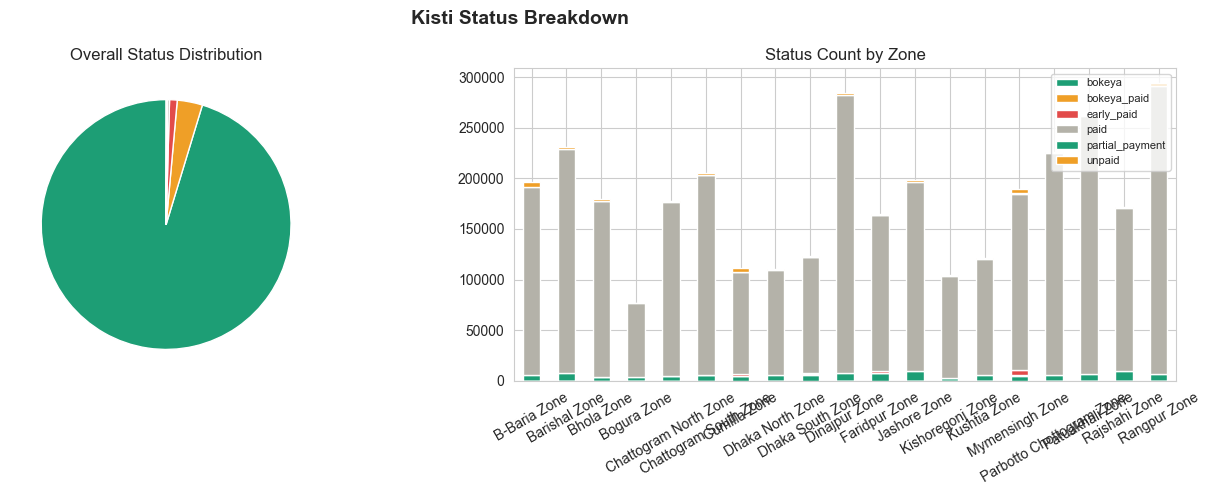

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kisti Status Breakdown", fontsize=14, fontweight="bold")

# Pie
status_dist.plot.pie(
    ax=axes[0],
    colors=["#1D9E75", "#EF9F27", "#E24B4A", "#B4B2A9"][:len(status_dist)],
    startangle=90,
    labels=None,
    ylabel="",
    autopct=None
)

axes[0].set_title("Overall Status Distribution")

# Stacked bar
pivot_count.plot(kind="bar", stacked=True, ax=axes[1],
                 color=["#1D9E75","#EF9F27","#E24B4A","#B4B2A9"][:pivot_count.shape[1]])
axes[1].set_title("Status Count by Zone")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("04_kisti_status.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# numeric_cols = [
#         "loan_amount",
#         "balance",
#         "kisti_amount",
#         "paid_amount",
#         "interest_recovery_rate",
#         "delay_days"
#     ]
#
# for col in numeric_cols:
#     df[col] = pd.to_numeric(df[col], errors="coerce")
#
# product_perf = (
#     df.groupby("loan_component", dropna=False)
#     .agg(
#         total_loans            = ("loan_id", "nunique"),
#         total_disbursed        = ("loan_amount", "sum"),
#         total_balance          = ("balance", "sum"),
#         total_scheduled        = ("kisti_amount", "sum"),
#         total_collected        = ("paid_amount", "sum"),
#         avg_interest_recovery  = ("interest_recovery_rate", "mean"),
#         avg_delay              = ("delay_days", "mean"),
#     )
#     .assign(
#         collection_rate = lambda x:
#             safe_div(x["total_collected"], x["total_scheduled"]) * 100,
#
#         recovery_ratio = lambda x:
#             safe_div(x["total_balance"], x["total_disbursed"]) * 100,
#     )
#     .reset_index()
#     .sort_values("collection_rate", ascending=False)
# )
#
# print(product_perf.to_string(index=False))

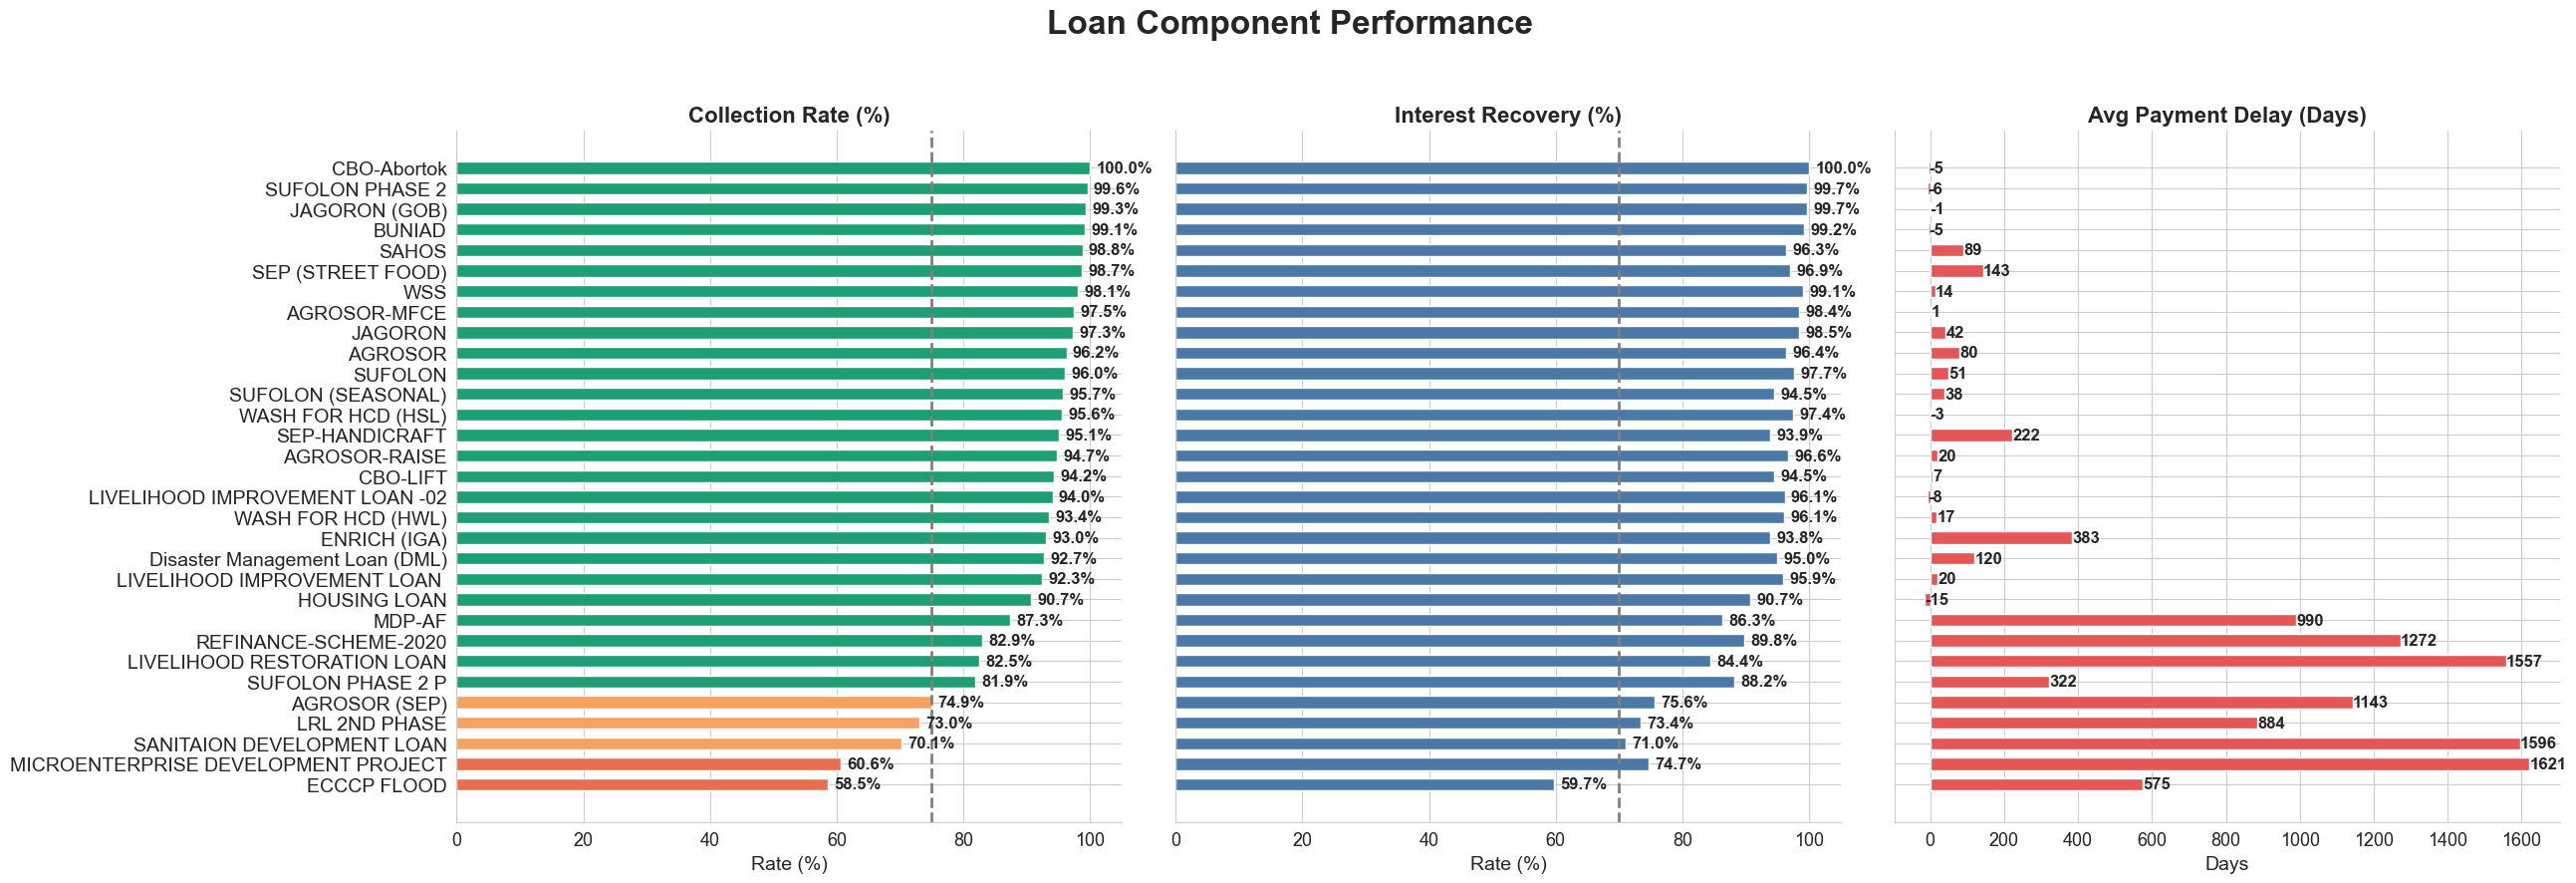

In [139]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(26, 9), sharey=True)
fig.suptitle("Loan Component Performance", fontsize=24, fontweight="bold")

df = product_perf.sort_values("collection_rate")

colors = df["collection_rate"].apply(
    lambda r: "#1D9E75" if r >= 80 else "#F4A261" if r >= 65 else "#E76F51"
)

BAR_HEIGHT = 0.6  # thicker bars

# ---------- 1. Collection Rate ----------
axes[0].barh(df["loan_component"], df["collection_rate"],
             color=colors, height=BAR_HEIGHT)

axes[0].axvline(75, ls="--", lw=2, color="gray")
axes[0].set_title("Collection Rate (%)", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Rate (%)", fontsize=14)

axes[0].tick_params(axis='x', labelsize=13)
axes[0].tick_params(axis='y', labelsize=14)

for i, v in enumerate(df["collection_rate"]):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=12, fontweight="bold")

# ---------- 2. Interest Recovery ----------
axes[1].barh(df["loan_component"], df["avg_interest_recovery"].fillna(0),
             color="#4C78A8", height=BAR_HEIGHT)

axes[1].axvline(70, ls="--", lw=2, color="gray")
axes[1].set_title("Interest Recovery (%)", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Rate (%)", fontsize=14)

axes[1].tick_params(axis='x', labelsize=13)
axes[1].tick_params(axis='y', labelsize=14)

for i, v in enumerate(df["avg_interest_recovery"].fillna(0)):
    axes[1].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=12, fontweight="bold")

# ---------- 3. Avg Delay ----------
axes[2].barh(df["loan_component"], df["avg_delay"].fillna(0),
             color="#E45756", height=BAR_HEIGHT)

axes[2].set_title("Avg Payment Delay (Days)", fontsize=16, fontweight="bold")
axes[2].set_xlabel("Days", fontsize=14)

axes[2].tick_params(axis='x', labelsize=13)
axes[2].tick_params(axis='y', labelsize=14)

for i, v in enumerate(df["avg_delay"].fillna(0)):
    axes[2].text(v + 0.5, i, f"{v:.0f}", va="center", fontsize=12, fontweight="bold")

# ---------- clean look ----------
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("05_product_performance.png", dpi=300, bbox_inches="tight")
plt.show()

In [131]:
numeric_cols = [
    "overdue",
    "delay_days",
    "balance"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Ensure boolean column
df["is_paid"] = df["is_paid"].fillna(False).astype(bool)

# risk member indicators
member_risk = (
    df.groupby("member_id", dropna=False)
    .agg(
        total_installments=("schedule_id", "count"),

        missed_payments=(
            "is_paid",
            lambda x: (~x).sum()
        ),

        total_overdue=("overdue", "max"),

        max_delay_days=("delay_days", "max"),

        avg_delay_days=("delay_days", "mean"),

        loan_count=("loan_id", "nunique"),

        total_balance=("balance", "mean"),

        zone=("zonename", "first"),

        loan_component=("loan_component", "first"),
    )
    .reset_index()
)
#member payment rate
member_risk["miss_rate"] = (
    safe_div(
        member_risk["missed_payments"],
        member_risk["total_installments"]
    ) * 100
)


In [133]:
print("\n── Risk distribution ──")
print(risk_dist.to_string())
print("\n── Top 20 high-risk members ──")
print(
    top_risk[
        [
            "member_id",
            "zone",
            "loan_component",
            "miss_rate",
            "avg_delay_days",
            "total_overdue",
            "risk_score",
            "risk_level"
        ]
    ].to_string(index=False)
)
print("\n── Zone × Risk Level ──")
print(zone_risk.to_string())


── Risk distribution ──
risk_level
Low         370098
High         35949
Medium       29350
Critical      2358

── Top 20 high-risk members ──
 member_id                     zone loan_component  miss_rate  avg_delay_days  total_overdue  risk_score risk_level
   1186766         Dhaka North Zone        AGROSOR      100.0           130.0        1300000       83.46   Critical
    221058               Bhola Zone        AGROSOR      100.0           931.0        1063880       78.84   Critical
   1071981         Kishoregonj Zone       CBO-LIFT      100.0           374.0         998540       77.56   Critical
   1117878         Dhaka South Zone        AGROSOR      100.0           310.0         959900       76.80   Critical
    448423             B-Baria Zone        AGROSOR      100.0           186.0         903385       75.70   Critical
   1048823         Dhaka North Zone        AGROSOR      100.0           374.0         790840       73.49   Critical
     15846         Dhaka North Zone        A

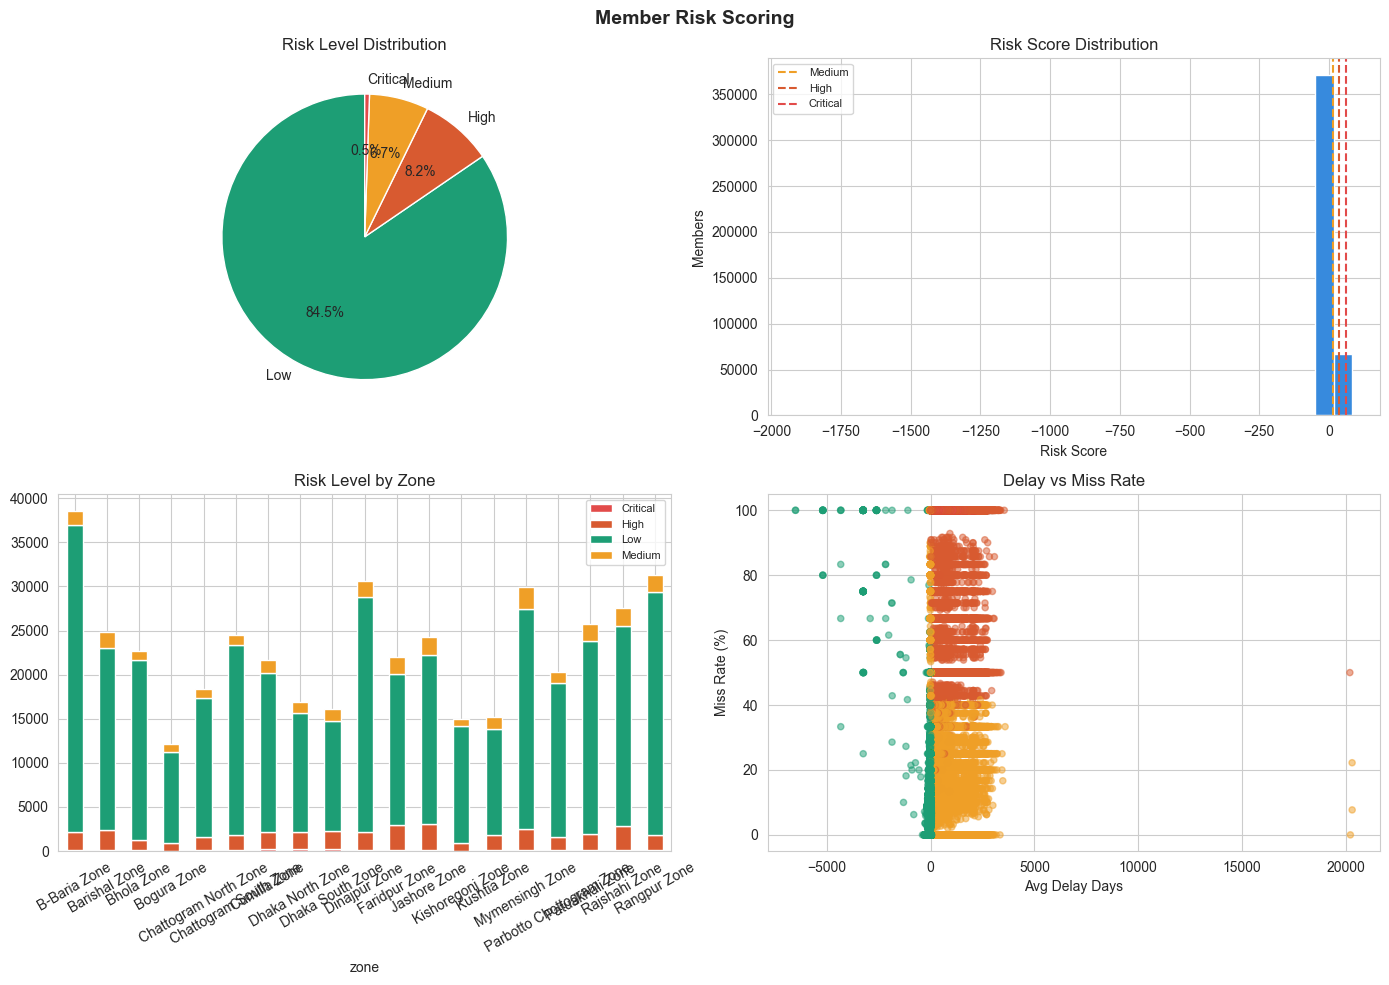

In [136]:
# Aggregate member-level risk indicators

member_risk = (
    df.groupby("member_id", dropna=False)
    .agg(
        total_installments=("schedule_id", "count"),

        missed_payments=(
            "is_paid",
            lambda x: (~x).sum()
        ),

        total_overdue=("overdue", "max"),

        max_delay_days=("delay_days", "max"),

        avg_delay_days=("delay_days", "mean"),

        loan_count=("loan_id", "nunique"),

        total_balance=("balance", "mean"),

        zone=("zonename", "first"),

        loan_component=("loan_component", "first"),
    )
    .reset_index()
)


# Missed payment rate
member_risk["miss_rate"] = (
    safe_div(
        member_risk["missed_payments"],
        member_risk["total_installments"]
    ) * 100
)


# Normalize overdue safely
max_overdue = max(
    member_risk["total_overdue"].fillna(0).max(),
    1
)

# Composite risk score
member_risk["risk_score"] = (
    member_risk["miss_rate"] * 0.40 +

    member_risk["avg_delay_days"]
    .fillna(0)
    .clip(upper=60) * 0.30 +

    (
        member_risk["total_overdue"]
        .fillna(0) / max_overdue
    ) * 100 * 0.30

).round(2)

# Risk classification

def risk_level(score):

    if score >= 60:
        return "Critical"

    if score >= 35:
        return "High"

    if score >= 15:
        return "Medium"

    return "Low"

member_risk["risk_level"] = (
    member_risk["risk_score"]
    .apply(risk_level)
)


# Distribution summary

risk_dist = member_risk["risk_level"].value_counts()

# print("\n── Risk distribution ──")
# print(risk_dist.to_string())


# Top risky members

# print("\n── Top 20 high-risk members ──")

top_risk = (
    member_risk
    .sort_values("risk_score", ascending=False)
    .head(20)
)

# print(
#     top_risk[

# Zone-wise risk distribution

zone_risk = (
    member_risk
    .groupby(["zone", "risk_level"])
    .size()
    .unstack(fill_value=0)
)


# Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    "Member Risk Scoring",
    fontsize=14,
    fontweight="bold"
)

risk_colors = {
    "Low": "#1D9E75",
    "Medium": "#EF9F27",
    "High": "#D85A30",
    "Critical": "#E24B4A"
}


# 1. Pie chart

colors_ordered = [
    risk_colors.get(c, "gray")
    for c in risk_dist.index
]

risk_dist.plot.pie(
    ax=axes[0, 0],
    autopct="%1.1f%%",
    colors=colors_ordered,
    startangle=90,
    ylabel="",
)

axes[0, 0].set_title("Risk Level Distribution")


# 2. Histogram

axes[0, 1].hist(
    member_risk["risk_score"],
    bins=30,
    color="#378ADD",
    edgecolor="white"
)

for thresh, color, label in [
    (15, "#EF9F27", "Medium"),
    (35, "#D85A30", "High"),
    (60, "#E24B4A", "Critical")
]:

    axes[0, 1].axvline(
        thresh,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=label
    )

axes[0, 1].set_xlabel("Risk Score")
axes[0, 1].set_ylabel("Members")
axes[0, 1].set_title("Risk Score Distribution")
axes[0, 1].legend(fontsize=8)


# 3. Zone-wise stacked bar

if not zone_risk.empty:

    zone_risk.plot(
        kind="bar",
        stacked=True,
        ax=axes[1, 0],
        color=[
            risk_colors.get(c, "gray")
            for c in zone_risk.columns
        ]
    )

    axes[1, 0].set_title("Risk Level by Zone")

    axes[1, 0].tick_params(
        axis="x",
        rotation=30
    )

    axes[1, 0].legend(
        loc="upper right",
        fontsize=8
    )


# 4. Scatter plot

scatter_colors = (
    member_risk["risk_level"]
    .map(risk_colors)
    .fillna("gray")
)

axes[1, 1].scatter(
    member_risk["avg_delay_days"].fillna(0),
    member_risk["miss_rate"],
    c=scatter_colors,
    alpha=0.5,
    s=20
)

axes[1, 1].set_xlabel("Avg Delay Days")
axes[1, 1].set_ylabel("Miss Rate (%)")
axes[1, 1].set_title("Delay vs Miss Rate")


# Final layout

plt.tight_layout()

plt.savefig(
    "07_member_risk_scoring.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Export CSV

member_risk.sort_values(
    "risk_score",
    ascending=False
).to_csv(
    "member_risk_scores.csv",
    index=False
)

# print("\n💾 Exported: member_risk_scores.csv")